1. What is feature extraction from the text/ image
2. why we need it
3. Why it is so difficult
4. What is the core idea and some technics

1. One hot encoding
        1. The one hot encoding takes the unique words from the corpus and create columns for unique words and if the word is present then will fill it as 1 and rest of them are 0's.
        2. based on the sentences it will create matrix (nested list)
        3. once you have matrix (vector) you need to create a neural network
        4. for example you will be having 5 unique words in the corpus, then one hot encoding also gives the 5 - dimensional vector
        5. for example there are 1000 unique words in a corpus, then your becomes a 1000 - dimensional vector

            ### one hot encoder is not recommended because if unique words count is increasing, then the dimensionality and complexity of the model is also increasing. and neurons and complexity is also increasing. computational cost is also increasing

            2. for example is you have a different question in testing, that information is not used in the training so we will get out of vocabulary issue
            3. computation is also increases because, 0 is nothing in one hot encoding but still we are doing computation in one hot encoding

### Bag of Words (BOW)

        1. Bag of words will work based on the count of word present in the entire corpus
        2. some of the o's we can still see
        3. Bow works based on frequency
        4. but this bow doesn't capture the semantic meaning

# BOW practical

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.DataFrame({"text":["people watch dswithbappy",
                         "dswithbappy watch dswithbappy",
                         "people write comment",
                          "dswithbappy write comment"],"output":[1,1,0,0]})

df

,text,output
0,people watch dswithbappy,1
1,dswithbappy watch dswithbappy,1
2,people write comment,0
3,dswithbappy write comment,0


In [3]:
from sklearn.feature_extraction.text import CountVectorizer # this lib will help us to perform the BOW technique
cv = CountVectorizer()

In [4]:
bow = cv.fit_transform(df['text'])

In [5]:
print(cv.vocabulary_)

{'people': 2, 'watch': 3, 'dswithbappy': 1, 'write': 4, 'comment': 0}


In [6]:
bow.toarray()

array([[0, 1, 1, 1, 0],
       [0, 2, 0, 1, 0],
       [1, 0, 1, 0, 1],
       [1, 1, 0, 0, 1]])

In [7]:
# new sentence
cv.transform(['Bappy watch dswithbappy']).toarray()

array([[0, 1, 0, 1, 0]])

In [8]:
X = bow.toarray()
y = df['output']

# n-gram

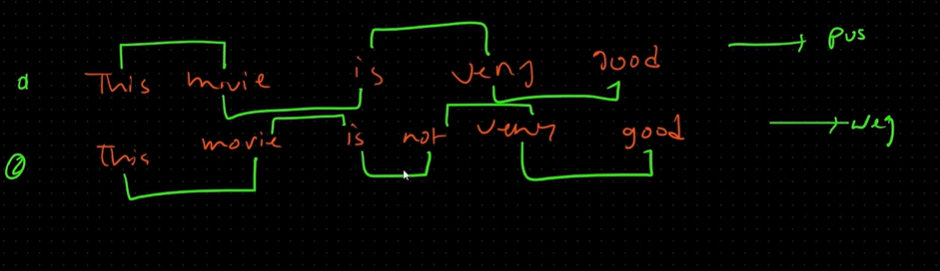

In [9]:
df = pd.DataFrame({"text":["people watch dswithbappy",
                         "dswithbappy watch dswithbappy",
                         "people write comment",
                          "dswithbappy write comment"],"output":[1,1,0,0]})

df

,text,output
0,people watch dswithbappy,1
1,dswithbappy watch dswithbappy,1
2,people write comment,0
3,dswithbappy write comment,0


In [10]:
# BI grams
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(2,2))

In [11]:
bow = cv.fit_transform(df['text'])

In [12]:
bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (4, 6)>

In [13]:
print(cv.vocabulary_)

{'people watch': 2, 'watch dswithbappy': 4, 'dswithbappy watch': 0, 'people write': 3, 'write comment': 5, 'dswithbappy write': 1}


In [14]:
print(bow[0].toarray())
print(bow[1].toarray())
print(bow[2].toarray())

[[0 0 1 0 1 0]]
[[1 0 0 0 1 0]]
[[0 0 0 1 0 1]]


### Trigram

In [16]:
#trigram
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(3,3))

In [17]:
bow = cv.fit_transform(df['text'])

In [18]:
print(cv.vocabulary_)

{'people watch dswithbappy': 2, 'dswithbappy watch dswithbappy': 0, 'people write comment': 3, 'dswithbappy write comment': 1}


In [19]:
print(bow[0].toarray())
print(bow[1].toarray())
print(bow[2].toarray())

[[0 0 1 0]]
[[1 0 0 0]]
[[0 0 0 1]]



## TF-IDF (Term frequency- Inverse document frequency)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid = TfidfVectorizer()

In [21]:
arr = tfid.fit_transform(df['text']).toarray()

In [23]:
arr # this will help to reduce the dimensionality of the vector, it will assign the weights

array([[0.        , 0.49681612, 0.61366674, 0.61366674, 0.        ],
       [0.        , 0.8508161 , 0.        , 0.52546357, 0.        ],
       [0.57735027, 0.        , 0.57735027, 0.        , 0.57735027],
       [0.61366674, 0.49681612, 0.        , 0.        , 0.61366674]])

In [24]:
# this is reducing the dimensionality of the vector but it is not capturing the semantic meaning

In [25]:
# so let's try with Word2Vec ==> this is a deep learning techique to convert the text to vector

In [26]:
tfid.idf_

array([1.51082562, 1.22314355, 1.51082562, 1.51082562, 1.51082562])

# Word2Vec

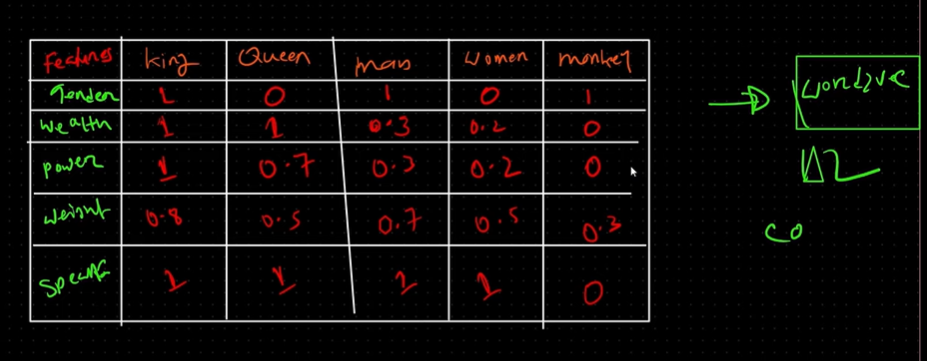

vectors of the king, women, man, women and monkey

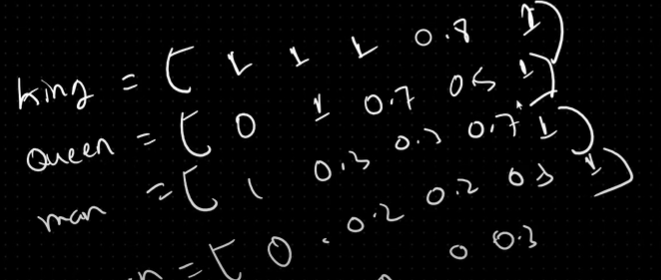

1. The deep learning model is generated the an array (features of text)
2. if you plot graph, the king and queen vectors will come close together because both are similar and distance is also very less

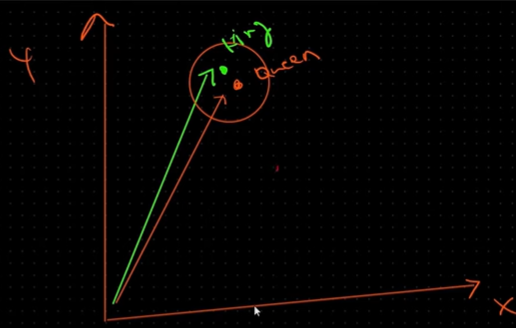

1. if you see the man and women they similar and they considered as a cluster
2. if you look at monkey, it is a different entity 
3. if you write a column like princess, this will comes to the king and queen cluster because the features are similar


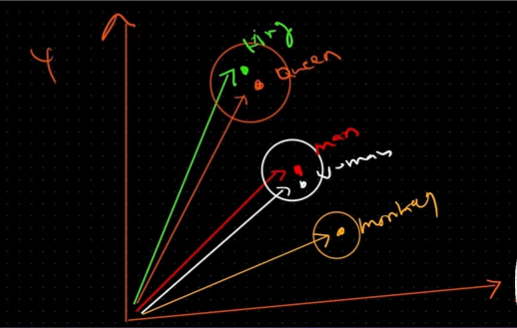
